<p style="align: center;"><img src="https://static.tildacdn.com/tild6636-3531-4239-b465-376364646465/Deep_Learning_School.png" width="400"></p>

# Домашнее задание. Обучение языковой модели с помощью LSTM (10 баллов)

Э
В этом задании Вам предстоит обучить языковую модель с помощью рекуррентной нейронной сети. В отличие от семинарского занятия, Вам необходимо будет работать с отдельными словами, а не буквами.


Установим модуль ```datasets```, чтобы нам проще было работать с данными.

In [1]:
!pip install -q datasets

Импорт необходимых библиотек

In [2]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import numpy as np
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from datasets import load_dataset
from nltk.tokenize import sent_tokenize, word_tokenize
from sklearn.model_selection import train_test_split
import nltk

from collections import Counter
from typing import List

import seaborn
seaborn.set(palette='summer')

In [3]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /usr/share/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [4]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

## Подготовка данных

Воспользуемся датасетом imdb. В нем хранятся отзывы о фильмах с сайта imdb. Загрузим данные с помощью функции ```load_dataset```

In [5]:
# Загрузим датасет
dataset = load_dataset('imdb')

### Препроцессинг данных и создание словаря (1 балл)

Далее вам необходмо самостоятельно произвести препроцессинг данных и получить словарь или же просто ```set``` строк. Что необходимо сделать:

1. Разделить отдельные тренировочные примеры на отдельные предложения с помощью функции ```sent_tokenize``` из бибилиотеки ```nltk```. Каждое отдельное предложение будет одним тренировочным примером.
2. Оставить только те предложения, в которых меньше ```word_threshold``` слов.
3. Посчитать частоту вхождения каждого слова в оставшихся предложениях. Для деления предлоения на отдельные слова удобно использовать функцию ```word_tokenize```.
4. Создать объект ```vocab``` класса ```set```, положить в него служебные токены '\<unk\>', '\<bos\>', '\<eos\>', '\<pad\>' и vocab_size самых частовстречающихся слов.   

In [6]:
sentences = []
word_threshold = 32
vocab = {'<unk>', '<bos>', '<eos>', '<pad>'}
vocab_size = 40000
counter = Counter()

for text in tqdm(dataset["train"]["text"]):
    for sent in nltk.sent_tokenize(text.lower()):
        words = nltk.word_tokenize(sent)
        if len(words) < word_threshold:
            sentences.append(sent)
            counter.update(words)

print("total words: ", len(counter))
vocab.update(word for word, count in counter.most_common(vocab_size))

  0%|          | 0/25000 [00:00<?, ?it/s]

total words:  67995


In [7]:
print("Всего предложений:", len(sentences))

Всего предложений: 195520


Посчитаем для каждого слова его встречаемость.

In [ ]:
# сделал выше /\
#             ||

Добавим в словарь ```vocab_size``` самых встречающихся слов.

In [ ]:
# сделал выше /\
#             ||

In [16]:
assert '<unk>' in vocab
assert '<bos>' in vocab
assert '<eos>' in vocab
assert '<pad>' in vocab
assert len(vocab) == vocab_size + 4

In [8]:
print("Всего слов в словаре:", len(vocab))

Всего слов в словаре: 40004


### Подготовка датасета (1 балл)

Далее, как и в семинарском занятии, подготовим датасеты и даталоадеры.

В классе ```WordDataset``` вам необходимо реализовать метод ```__getitem__```, который будет возвращать сэмпл данных по входному idx, то есть список целых чисел (индексов слов).

Внутри этого метода необходимо добавить служебные токены начала и конца последовательности, а также токенизировать соответствующее предложение с помощью ```word_tokenize``` и сопоставить ему индексы из ```word2ind```.

In [9]:
word2ind = {char: i for i, char in enumerate(vocab)}
ind2word = {i: char for char, i in word2ind.items()}

In [10]:
class WordDataset:
    def __init__(self, sentences):
        self.data = sentences
        self.unk_id = word2ind['<unk>']
        self.bos_id = word2ind['<bos>']
        self.eos_id = word2ind['<eos>']
        self.pad_id = word2ind['<pad>']

    def __getitem__(self, idx: int) -> List[int]:
        tokenized_sentence = []
        tokenized_sentence.append(self.bos_id)
        tokenized_sentence.extend([word2ind.get(word, self.unk_id) for word in nltk.word_tokenize(self.data[idx])])
        tokenized_sentence.append(self.eos_id)
        return tokenized_sentence

    def __len__(self) -> int:
        return len(self.data)

In [11]:
def collate_fn_with_padding(
    input_batch: List[List[int]], pad_id=word2ind['<pad>']) -> torch.Tensor:
    seq_lens = [len(x) for x in input_batch]
    max_seq_len = max(seq_lens)

    new_batch = []
    for sequence in input_batch:
        for _ in range(max_seq_len - len(sequence)):
            sequence.append(pad_id)
        new_batch.append(sequence)

    sequences = torch.LongTensor(new_batch).to(device)

    new_batch = {
        'input_ids': sequences[:,:-1],
        'target_ids': sequences[:,1:]
    }

    return new_batch

In [12]:
train_sentences, eval_sentences = train_test_split(sentences, test_size=0.2)
eval_sentences, test_sentences = train_test_split(sentences, test_size=0.5)

train_dataset = WordDataset(train_sentences)
eval_dataset = WordDataset(eval_sentences)
test_dataset = WordDataset(test_sentences)

batch_size = 128

train_dataloader = DataLoader(
    train_dataset, collate_fn=collate_fn_with_padding, batch_size=batch_size)

eval_dataloader = DataLoader(
    eval_dataset, collate_fn=collate_fn_with_padding, batch_size=batch_size)

test_dataloader = DataLoader(
    test_dataset, collate_fn=collate_fn_with_padding, batch_size=batch_size)

## Обучение и архитектура модели

Вам необходимо на практике проверить, что влияет на качество языковых моделей. В этом задании нужно провести серию экспериментов с различными вариантами языковых моделей и сравнить различия в конечной перплексии на тестовом множестве.

Возмоэные идеи для экспериментов:

* Различные RNN-блоки, например, LSTM или GRU. Также можно добавить сразу несколько RNN блоков друг над другом с помощью аргумента num_layers. Вам поможет официальная документация [здесь](https://pytorch.org/docs/stable/generated/torch.nn.LSTM.html)
* Различные размеры скрытого состояния. Различное количество линейных слоев после RNN-блока. Различные функции активации.
* Добавление нормализаций в виде Dropout, BatchNorm или LayerNorm
* Различные аргументы для оптимизации, например, подбор оптимального learning rate или тип алгоритма оптимизации SGD, Adam, RMSProp и другие
* Любые другие идеи и подходы

После проведения экспериментов необходимо составить таблицу результатов, в которой описан каждый эксперимент и посчитана перплексия на тестовом множестве.

Учтите, что эксперименты, которые различаются, например, только размером скрытого состояния или количеством линейных слоев считаются, как один эксперимент.

Успехов!

### Функция evaluate (1 балл)

Заполните функцию ```evaluate```

In [14]:
def evaluate(model, criterion, dataloader) -> float:
    model.eval()
    perplexity = []
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="eval"):
            logits = model(batch["input_ids"].to(device)).flatten(start_dim=0, end_dim=1)
            loss = criterion(logits, batch['target_ids'].flatten().to(device))
            perplexity.append(torch.exp(loss).item())

    perplexity = sum(perplexity) / len(perplexity)

    return perplexity

### Train loop (1 балл)

Напишите функцию для обучения модели.

In [31]:
from IPython.display import clear_output, display

def train_model(NUM_EPOCHS, train_dataloader, val_dataloader, model, criterion, optimizer, scheduler, number):
    losses = []
    ppx_train = []
    ppx_val = []

    min_ppx_val = float("inf")
    for ep in range(NUM_EPOCHS):
        losses_per_epoch = []
        ppx_per_epoch = []

        for batch in tqdm(train_dataloader, desc=f"Epoch {ep+1}"):

            model.train()
            optimizer.zero_grad()
            logits = model(batch["input_ids"].to(device)).flatten(start_dim=0, end_dim=1)
            loss = criterion(logits, batch["target_ids"].flatten().to(device))
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            losses_per_epoch.append(loss.item())
            ppx_per_epoch.append(torch.exp(loss).item())

        losses.append(sum(losses_per_epoch)/len(losses_per_epoch))
        ppx_train.append(sum(ppx_per_epoch)/len(ppx_per_epoch))
        ppx_val.append(evaluate(model, criterion, val_dataloader))

        if scheduler is not None:
            scheduler.step(ppx_val[-1])

        if ppx_val[-1] < min_ppx_val:
            min_ppx_val = ppx_val[-1]
            torch.save(model.state_dict(), f"/kaggle/working/best_model_{number}.pt")

        clear_output(wait=True)
        fig, ax = plt.subplots(1, 2, figsize=(12, 5))
        seaborn.lineplot(x=range(1, ep+2), y=ppx_train, ax=ax[0], label="train", color="orange")
        seaborn.lineplot(x=range(1, ep+2), y=ppx_val, ax=ax[0], label="val", color="lightblue")
        ax[0].set_title("perplexity")
        seaborn.lineplot(x=range(1, ep+2), y=losses, ax=ax[1], color="orange")
        ax[1].set_title("loss")
        plt.tight_layout()
        plt.show()
            
        print(f"Epoch {ep+1}, train_ppx = {ppx_train[-1]:.6f}, val_ppx = {ppx_val[-1]:.6f}")
    print(f"best reached score: {min_ppx_val:.6f}")

## Первый эксперимент (2 балла)

Определите архитектуру модели и обучите её.

In [16]:
class LanguageModel(nn.Module):
    def __init__(self, hidden_dim, vocab_size):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, hidden_dim)
        self.rnn = nn.GRU(hidden_dim, hidden_dim, batch_first=True)
        self.linear = nn.Linear(hidden_dim, hidden_dim)
        self.projection = nn.Linear(hidden_dim, vocab_size)

        self.non_lin = nn.Tanh()
        self.dropout = nn.Dropout(p=0.3)

    def forward(self, input_batch: torch.Tensor) -> torch.Tensor:
        embeddings = self.embedding(input_batch)
        output, _ = self.rnn(embeddings)
        output = self.dropout(self.linear(self.non_lin(output)))
        projection = self.projection(self.non_lin(output))
        return projection

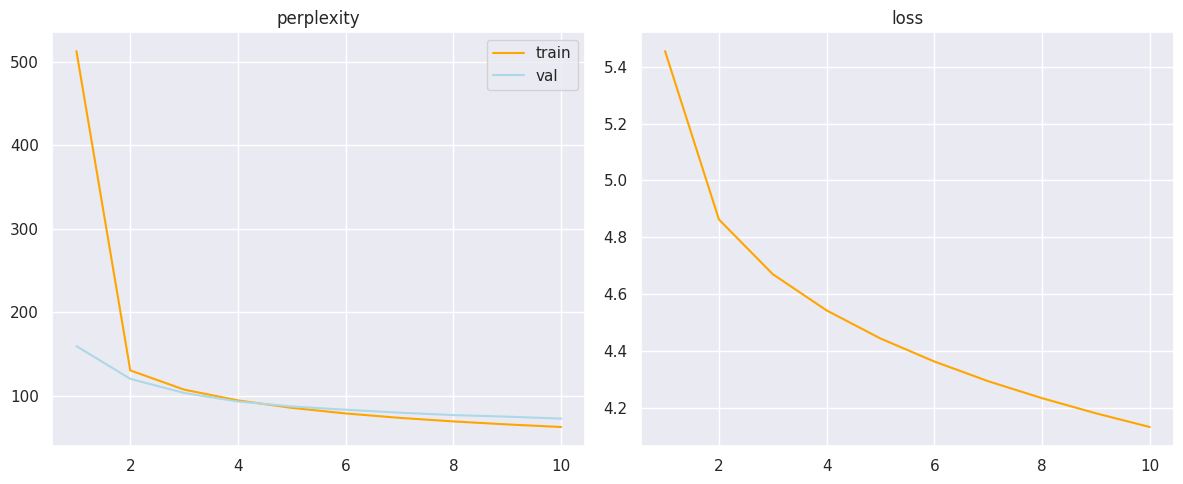

Epoch 10, train_ppx = 62.465582, val_ppx = 72.536152
best reached score: 72.536152


In [53]:
model = LanguageModel(256, 40004).to(device)
criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
optimizer = torch.optim.Adam(model.parameters(), lr = 1e-3)
train_model(10, train_dataloader, eval_dataloader, model, criterion, optimizer, None, 1)

In [55]:
model.load_state_dict(torch.load("/kaggle/working/best_model_1.pt"))
res = evaluate(model, criterion, test_dataloader)
print(f"reached {res:.6f} on test")

eval:   0%|          | 0/764 [00:00<?, ?it/s]

reached 72.869704 on test


## Второй эксперимент (2 балла)

Попробуйте что-то поменять в модели или в пайплайне обучения, идеи для экспериментов можно подсмотреть выше.

In [17]:
class LM2(LanguageModel):
    def __init__(self, hidden_dim, vocab_size):
        super().__init__(hidden_dim, vocab_size)
        self.rnn = nn.GRU(hidden_dim, hidden_dim, batch_first=True, num_layers=2)

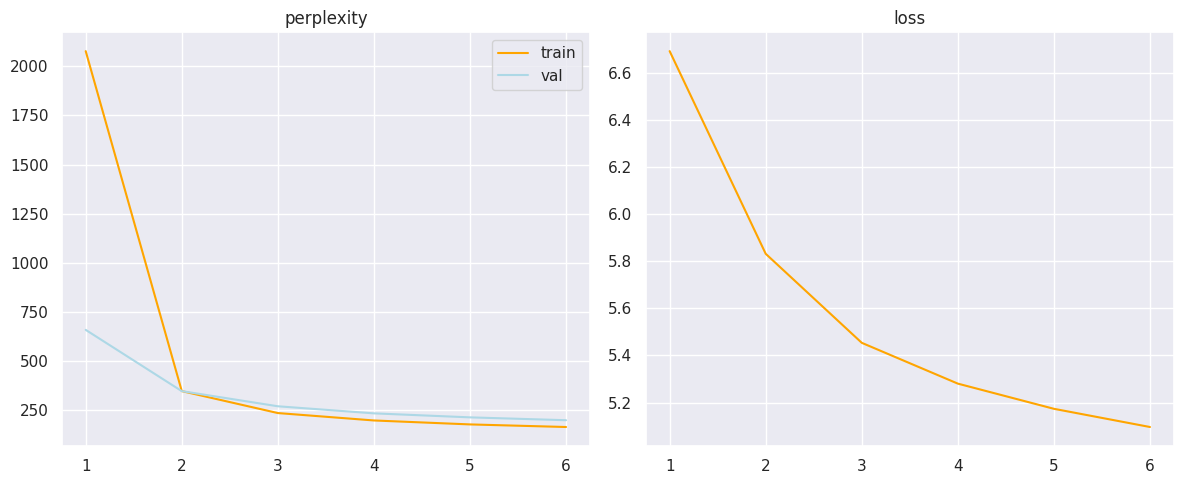

Epoch 6, train_ppx = 164.040637, val_ppx = 198.633564


Epoch 7:   0%|          | 0/1222 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [75]:
model = LM2(256, 40004).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr = 1e-4)
train_model(10, train_dataloader, eval_dataloader, model, criterion, optimizer, None, 2)

In [76]:
model.load_state_dict(torch.load("/kaggle/working/best_model_2.pt"))
res = evaluate(model, criterion, test_dataloader)
print(f"reached {res:.6f} on test")

eval:   0%|          | 0/764 [00:00<?, ?it/s]

reached 199.567763 on test


## Третий эксперимент

In [27]:
class LM3(LanguageModel):

    def __init__(self, hidden_dim, vocab_size):
        super().__init__(hidden_dim, vocab_size)
        self.layer_norm = nn.LayerNorm(hidden_dim)

    def forward(self, input_batch: torch.Tensor) -> torch.Tensor:
        embeddings = self.embedding(input_batch)
        output, _ = self.rnn(embeddings)
        output = self.dropout(self.linear(self.non_lin(self.layer_norm(output))))
        projection = self.projection(self.non_lin(output))
        return projection

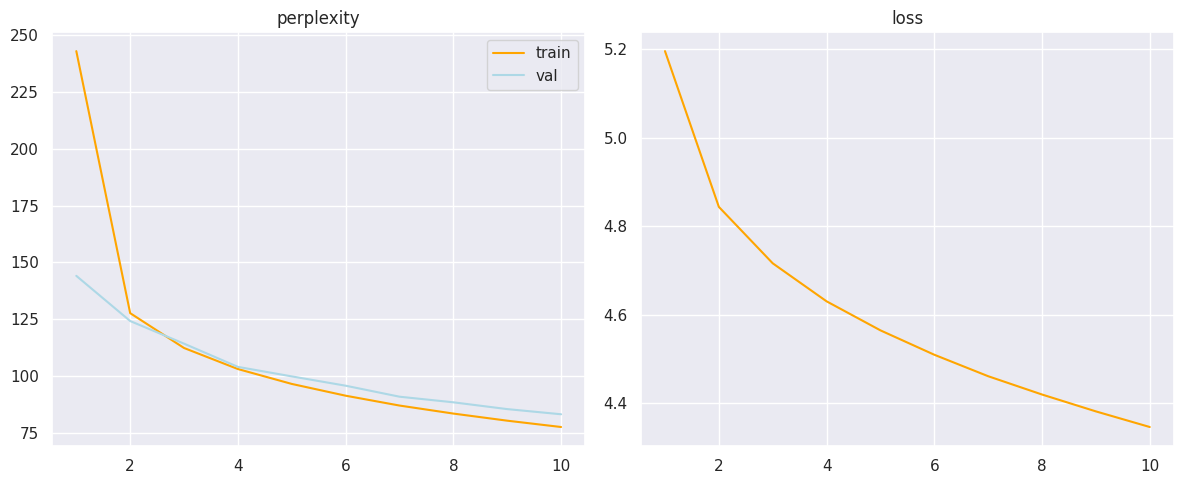

Epoch 10, train_ppx = 77.420687, val_ppx = 83.038160
best reached score: 83.038160


In [32]:
model = LM3(256, 40004).to(device)
criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
optimizer = torch.optim.RMSprop(model.parameters(), lr = 1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.75, patience=1)
train_model(10, train_dataloader, eval_dataloader, model, criterion, optimizer, scheduler, 3)

In [33]:
model.load_state_dict(torch.load("/kaggle/working/best_model_3.pt"))
res = evaluate(model, criterion, test_dataloader)
print(f"reached {res:.6f} on test")

eval:   0%|          | 0/764 [00:00<?, ?it/s]

reached 82.803715 on test


## Четвертый эксперимент

In [37]:
class LM4(LM2):
    
    def __init__(self, hidden_dim, vocab_size):
        super().__init__(hidden_dim, vocab_size)
        self.linear = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim)
        )

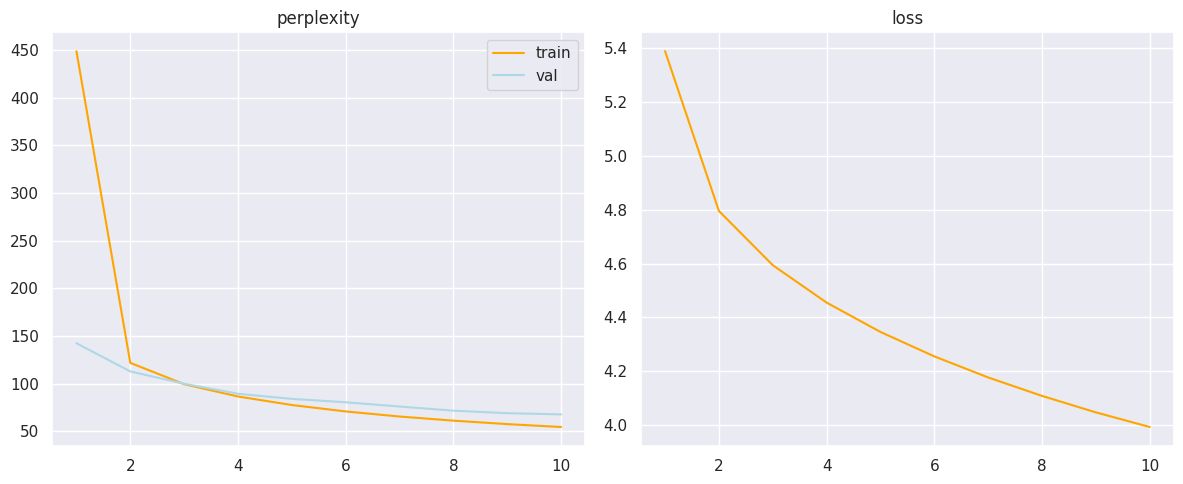

Epoch 10, train_ppx = 54.410003, val_ppx = 67.637490
best reached score: 67.637490


In [43]:
model = LanguageModel(320, 40004).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr = 1e-3)
train_model(10, train_dataloader, eval_dataloader, model, criterion, optimizer, None, 4)

In [44]:
model.load_state_dict(torch.load("/kaggle/working/best_model_4.pt"))
res = evaluate(model, criterion, test_dataloader)
print(f"reached {res:.6f} on test")

eval:   0%|          | 0/764 [00:00<?, ?it/s]

reached 67.466623 on test


## Отчет (2 балла)

С экспериментами особо не задалось. Поставил 2 GRU - обучение (сходимость) сильно ухудшилась. На бейзлайне было 72.87 на тесте, на 2xGRU дошел только до 6 эпохи, 199.57, но далее все обучалось еще хуже. RMSprop как будто только ухудшает -- с weight decay или без. 82.8 получил после 10 эпох с layer_norm. Пробовал 2 линейных слоя -- плохо, 2 линейных слоя + hidden_dim 512 -- сильное переобучение при качестве на валидации не лучше бейзлайна. Заметна тенденция что усложнение архитектуры и увеличение числа параметров не дает выигрыша. Лучшие 67.47 добился при увеличении скрытого состояния (256 -> 320) на бейзлайне (бейзлайн у меня с GRU) после 10 эпох.

Рекомендации для уменьшения перплексии: прогнать больше эпох с шедулером бейзлайн с 320 hidden_dim, я этого не делал так как не было задачи выбить определенный скор. Ну или использовать transformer-based архитектуры =)